Loading data set from c:/users/omer/rl-qecc-data/supervisedLearning\codeEvaluationTrainingData\l_21_m_18
loadCodeEvaluations: kept 4182 codes on the requested grid; dropped 385 records whose grid does not contain all its points
4182 codes were loaded
4182 codes were loaded


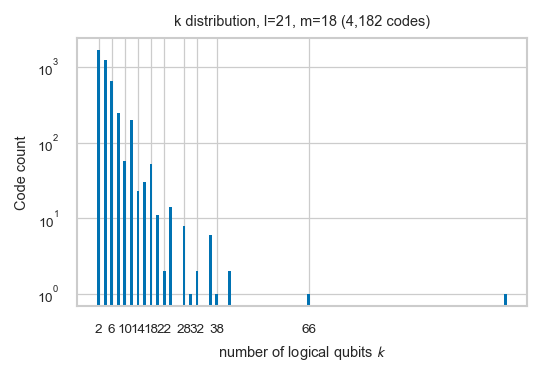

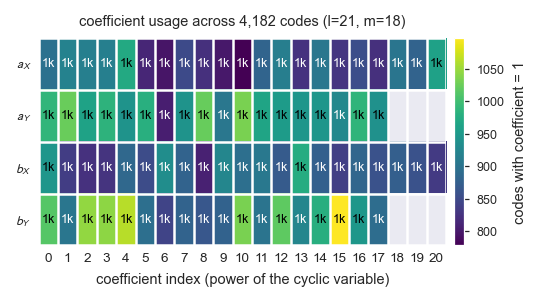

Loading data set from c:/users/omer/rl-qecc-data/supervisedLearning\codeEvaluationTrainingData\l_3_m_27


ValueError: No records found for l=3, m=27 under c:/users/omer/rl-qecc-data/supervisedLearning\codeEvaluationTrainingData\l_3_m_27

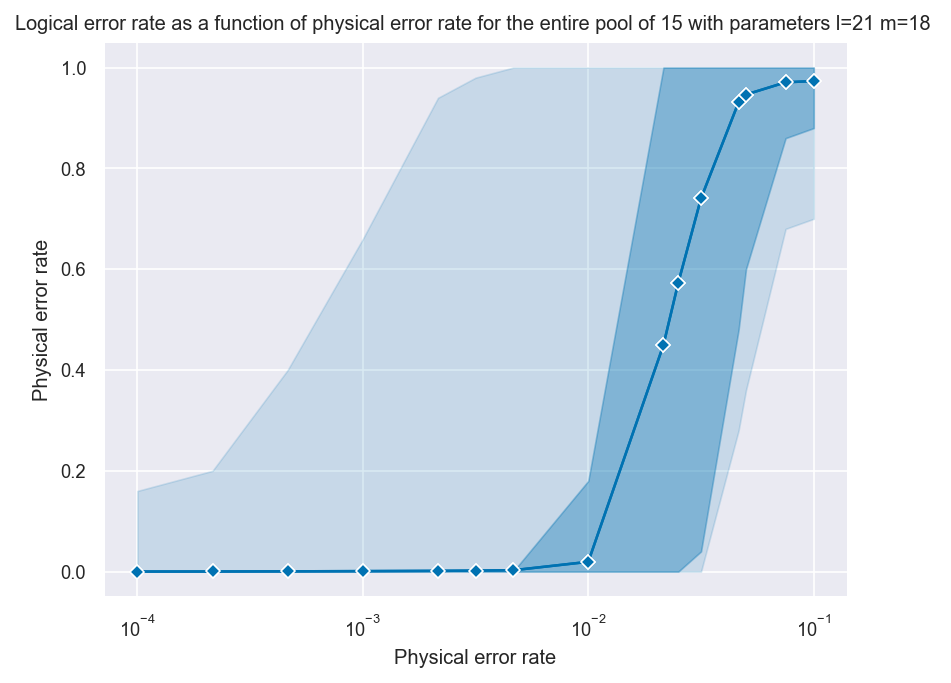

In [51]:
from qecc.codeEvaluationDataset import loadCodeEvaluations
import os
from qecc.utils import NAMED_ERROR_RANGES, CANONICAL_ERROR_RANGE, GEOMETRIC5_ERROR_RANGE
SAVE_PATH = os.path.join(os.environ.get("QECC_PAPER"), "art")

allSizes = ((6,6), (9,6),(12,6),(15,3),
            (21,18), (3,27),(5,15))
for l,m in ((21,18), (3,27),(5,15)):

    dataPath = os.path.join(os.environ.get("QECC_DATA"), "supervisedLearning", "codeEvaluationTrainingData", f"l_{l}_m_{m}")
    print(f"Loading data set from {dataPath}")
    errorRangeName = "union"
    errorRange = NAMED_ERROR_RANGES[errorRangeName]
    codes = loadCodeEvaluations(dataPath, l, m, errorRange=errorRange)
    print(f"{codes.bits.shape[0]} codes were loaded")

    # Plot the distribution of number of logical qubits
    print(f"{codes.bits.shape[0]} codes were loaded")
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    SAVE_PATH = os.path.join(os.environ.get("QECC_PAPER"), "art")
    sns.set_theme(style="whitegrid", context="paper")
    # plt.rcParams.update({
    #     "font.family": "Arial", "font.size": 7, "axes.labelsize": 7,
    #     "xtick.labelsize": 6.5, "ytick.labelsize": 6.5, "axes.linewidth": 0.6,
    #     "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    #     "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    #     "axes.spines.top": False, "axes.spines.right": False,
    #     "pdf.fonttype": 42, "mathtext.fontset": "stixsans",
    #     "figure.dpi": 150,   # crisp inline display; savefig overrides below
    # })

    plt.rcParams.update({                              # ...then print params win on top
        "font.family": "Arial", "font.size": 7, "axes.labelsize": 7,
        "axes.titlesize": 7, "xtick.labelsize": 6.5, "ytick.labelsize": 6.5,
        "legend.fontsize": 6.5, "legend.frameon": False,
        "grid.linewidth": 0.6,
        "pdf.fonttype": 42, "mathtext.fontset": "stixsans",
        "figure.dpi": 150,
    })
    #sns.histplot(codes.k, bins = 20, color = 'skyblue', log_scale=(True, False))
    #sns.heatmap(codes.bits)
    # bits = tuple(foldedAX) + tuple(foldedAY) + tuple(foldedBX) + tuple(foldedBY)

    import numpy as np

    kValues, kCounts = np.unique(codes.k, return_counts=True)

    fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)
    ax.bar(kValues, kCounts, width=0.85, color="#0072B2", lw=0)
    ax.set_yscale("log")
    ax.set_xlabel("number of logical qubits $k$")
    ax.set_ylabel("Code count")
    ax.set_xticks(kValues[::2])




    #plt.figure(figsize=(8, 4))
    #sns.histplot(codes.k, discrete=True, color='skyblue')
    #plt.yscale('log')   # counts span orders of magnitude; log on y keeps k=0 visible
    #plt.xlabel('number of logical qubits k')

    plt.title(f'k distribution, l={l}, m={m} ({codes.k.shape[0]:,} codes)')
    fig.savefig(os.path.join(SAVE_PATH, f"kDistribution_l_{l}_m_{m}.png"),  dpi=600)
    plt.show()

    # Plot the per polynomial coefficient hit count
    import numpy as np
    import matplotlib.colors as mcolors
    sns.set_theme(style="darkgrid", context="paper")   # seaborn aesthetic FIRST
    plt.rcParams.update({                              # ...then print params win on top
        "font.family": "Arial", "font.size": 7, "axes.labelsize": 7,
        "axes.titlesize": 7, "xtick.labelsize": 6.5, "ytick.labelsize": 6.5,
        "legend.fontsize": 6.5, "legend.frameon": False,
        "grid.linewidth": 0.6,
        "pdf.fonttype": 42, "mathtext.fontset": "stixsans",
        "figure.dpi": 150,
    })


    hits = codes.bits.astype(np.int64).sum(axis=0)   # int8 would overflow at 1.3M rows
    # segments = [('aX', l), ('aY', m), ('bX', l), ('bY', m)]
    # width = max(l, m)
    # grid = np.full((4, width), np.nan)
    # start = 0
    # for row, (name, n) in enumerate(segments):
    #     grid[row, :n] = hits[start:start + n]
    #     start += n

    # plt.figure(figsize=(1.0 * width, 3.2))
    # sns.heatmap(grid, annot=True, fmt='.0f', cmap='Blues',
    #             yticklabels=[name for name, _ in segments],
    #             xticklabels=range(width),
    #             cbar_kws={'label': 'codes with coefficient = 1'},)# norm=mcolors.LogNorm())
    # plt.xlabel('coefficient index')
    # plt.title(f'coefficient usage across {codes.bits.shape[0]:,} codes (l={l}, m={m})')
    # plt.show()
    hits = codes.bits.astype(np.int64).sum(axis=0)
    segments = [("$a_X$", l), ("$a_Y$", m), ("$b_X$", l), ("$b_Y$", m)]
    width = max(l, m)
    grid = np.full((4, width), np.nan)
    start = 0
    for row, (name, n) in enumerate(segments):
        grid[row, :n] = hits[start:start + n]
        start += n

    fig, ax = plt.subplots(figsize=(3.5, 1.9), constrained_layout=True)
    im = ax.imshow(grid, cmap="viridis", aspect="auto")
    threshold = (np.nanmin(grid) + np.nanmax(grid)) / 2
    for r in range(4):
        for c in range(width):
            if np.isfinite(grid[r, c]):
                ax.text(c, r, f"{grid[r, c]/1000:.0f}k", ha="center", va="center",
                        fontsize=6, color="white" if grid[r, c] < threshold else "black")
    ax.set_xticks(range(width))
    ax.set_yticks(range(4), [name for name, _ in segments])
    ax.set_xlabel("coefficient index (power of the cyclic variable)")
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.grid(False)                                        # kill the centre-of-cell major grid
    ax.set_xticks(np.arange(-0.5, width, 1), minor=True)  # minor ticks at the cell edges
    ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", length=0)
    cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cb.set_label("codes with coefficient = 1", size=7)
    cb.ax.tick_params(labelsize=6, width=0.6, length=2.5)
    cb.outline.set_linewidth(0.6)
    ax.set_title(f'coefficient usage across {codes.bits.shape[0]:,} codes (l={l}, m={m})')
    fig.savefig(os.path.join(SAVE_PATH, f"coefficientUsage_l_{l}_m_{m}_error_range_{errorRangeName}.png"), dpi = 600)
    plt.show()
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    sns.set_theme(style="darkgrid", context="paper")

    df = pd.DataFrame()

    rate = codes.counts / codes.samples[:,None]

    nCodes, nPoints = rate.shape
    df = pd.DataFrame({
        "errorRate": rate.ravel(),                  # row-major: code0's points, then code1's, ...
        "errorRange": np.tile(errorRange, nCodes),  # repeats [e0..en] per code, matches ravel order
        "k": np.repeat(codes.k, nPoints),            # repeats each k across its nPoints rows
    })
    df.keys()
    fig, ax = plt.subplots()
    #sns.lineplot(data=df, x="errorRange", y="errorRate", estimator="mean", errorbar=("pi",100), ax = ax)
    sns.lineplot(data=df, x="errorRange", y="errorRate", estimator="mean", marker = "D", markersize = 5,
                errorbar=("pi", 100), color="#0072B2", err_kws={"alpha": 0.15}, ax=ax)
    sns.lineplot(data=df, x="errorRange", y="errorRate", estimator="mean", marker = "D", markersize = 5,
                errorbar=("pi", 95), color="#0072B2", err_kws={"alpha": 0.35}, ax=ax)

    ax.set_xscale("log")
    ax.set_title(f"Logical error rate as a function of physical error rate for the entire pool of {codes.counts.shape[1]} with parameters l={l} m={m} ")
    ax.set_xlabel(f"Physical error rate")
    ax.set_ylabel(f"Physical error rate")
    fig.savefig(os.path.join(SAVE_PATH, f"per_qer_l_{l}_m_{m}_error_range_{errorRangeName}.png"), dpi = 600)

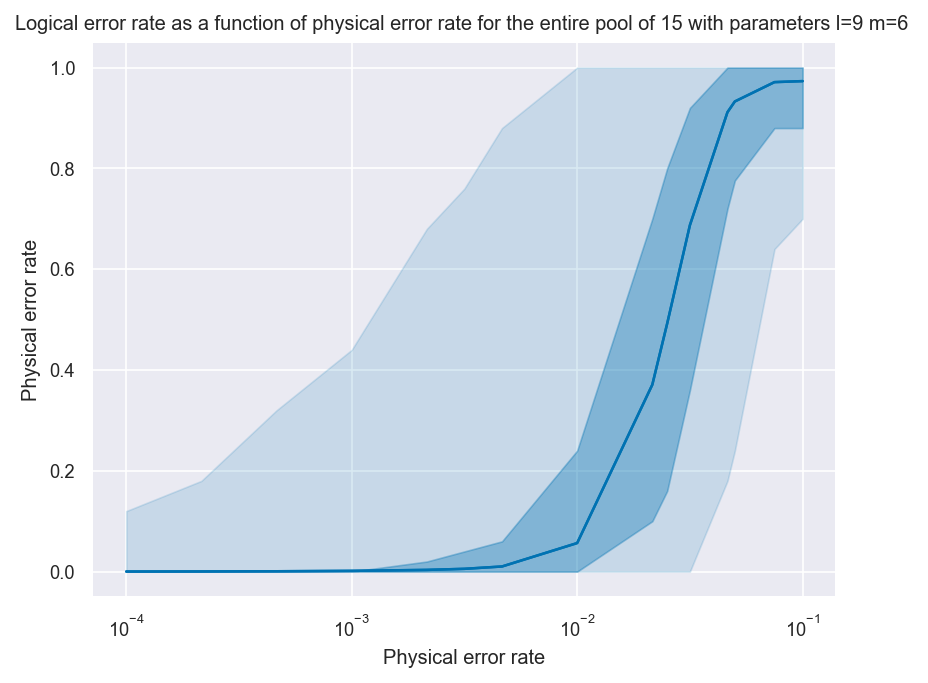

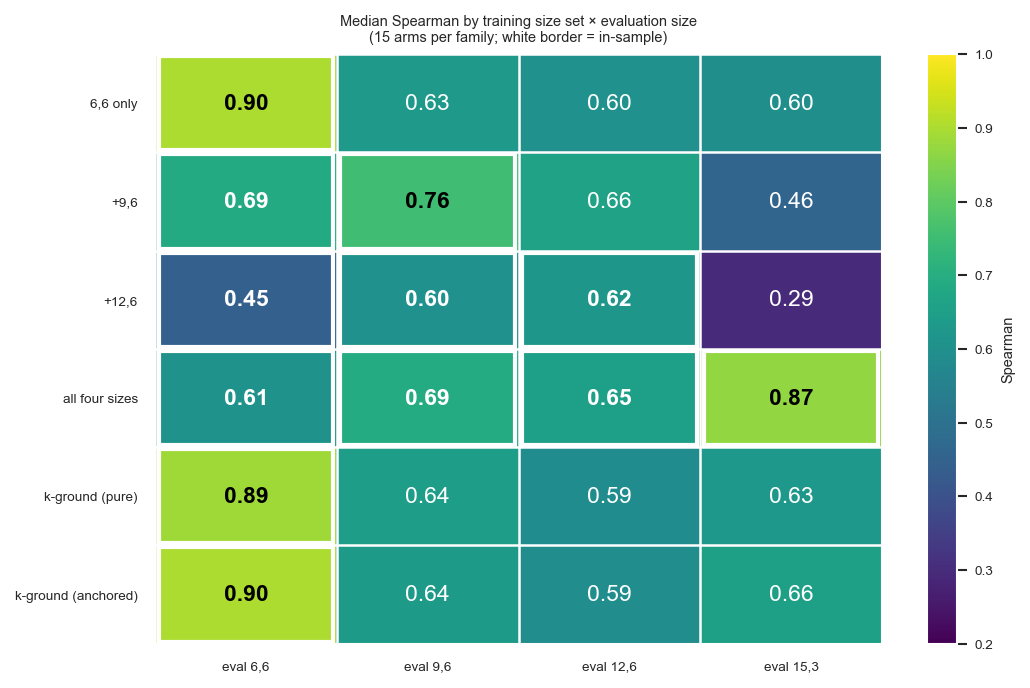

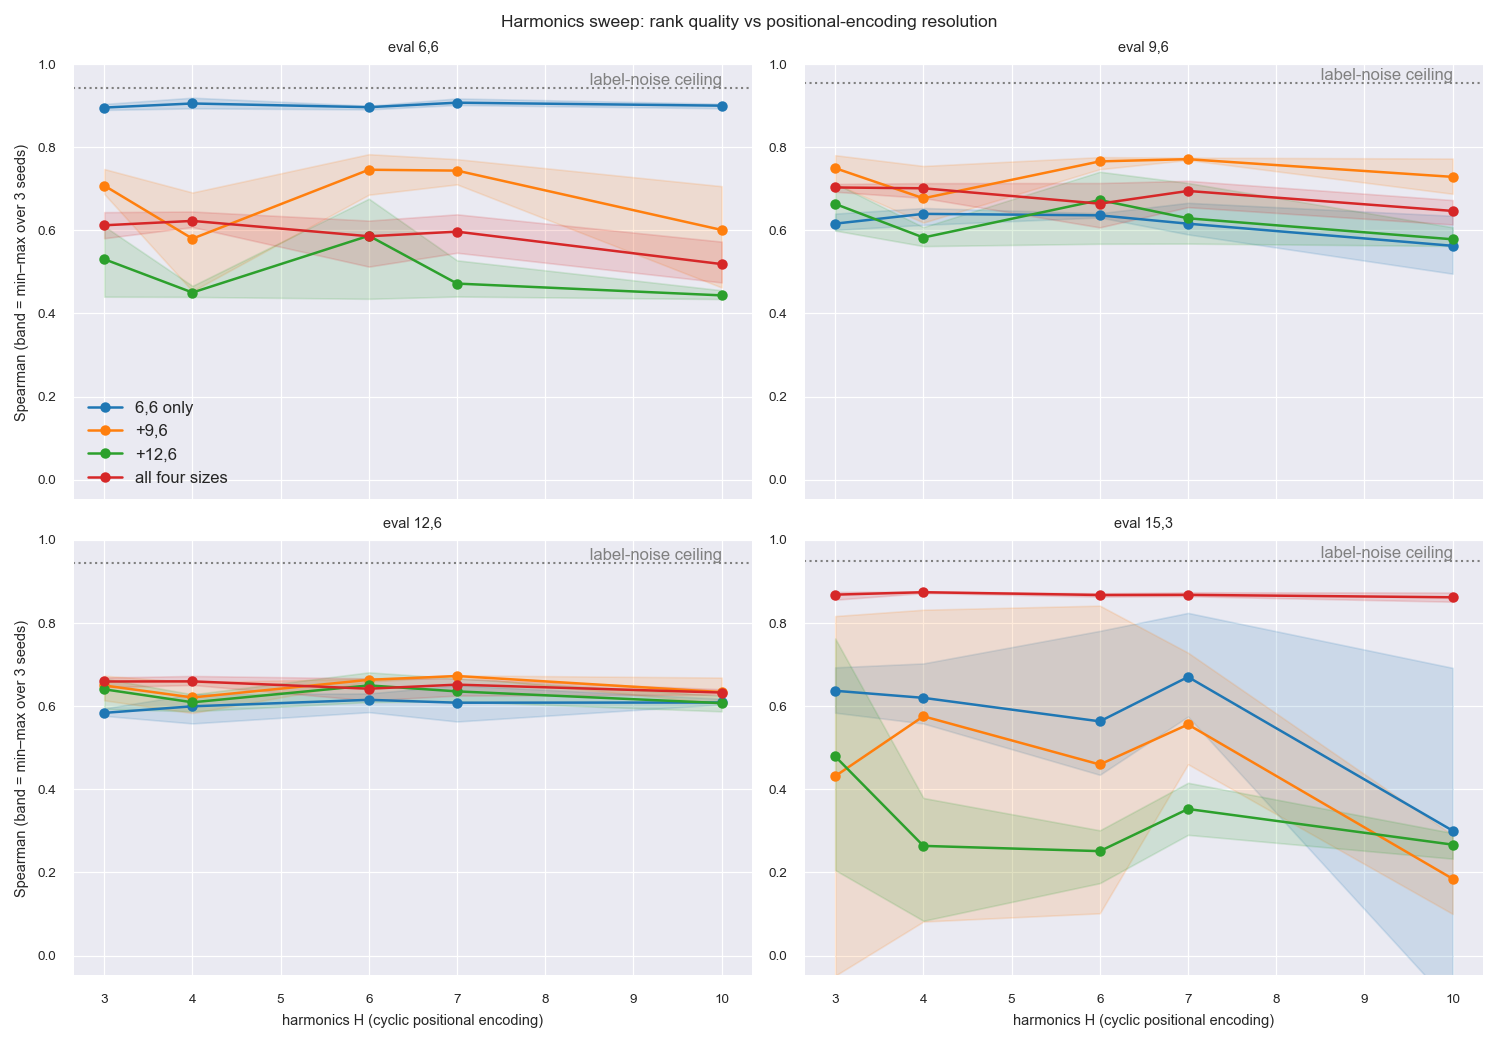

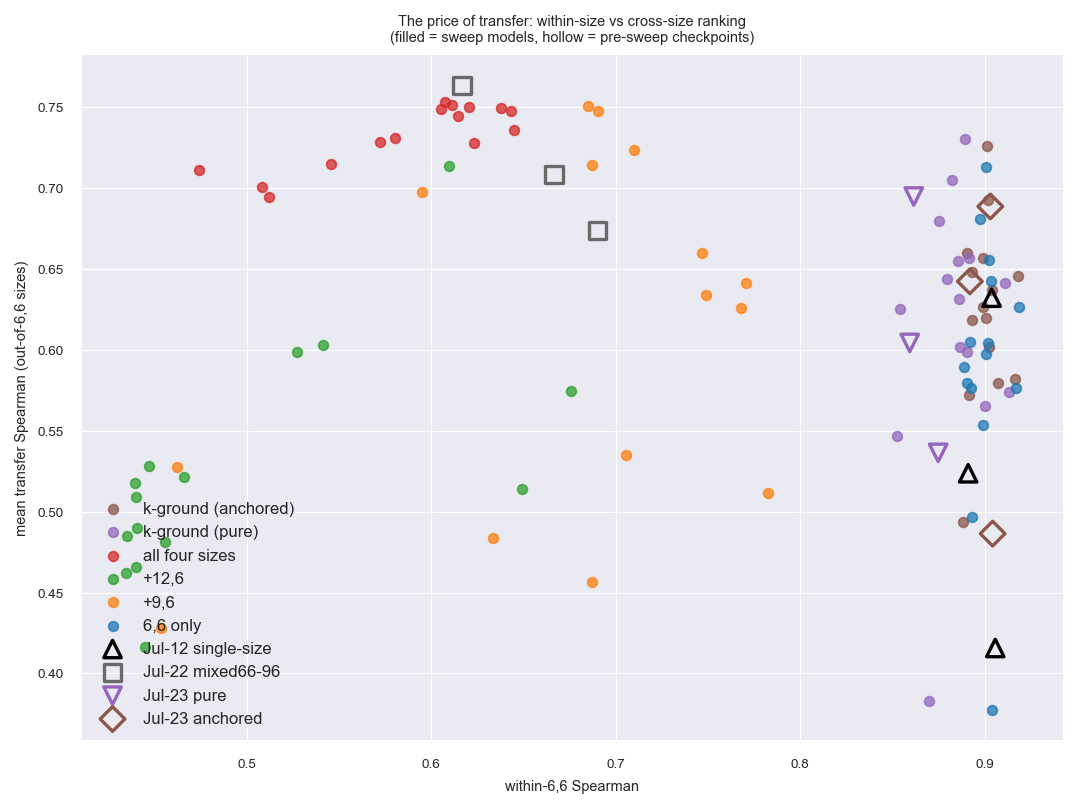

In [21]:
"""encoder sweep visualization sweep-analysis-fresh.csv
and oldModels_reEval.csv ."""
import csv
import re
from collections import defaultdict

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
sns.set_theme(style="darkgrid", context="paper")   # seaborn aesthetic FIRST
plt.rcParams.update({                              # ...then print params win on top
    "font.family": "Arial", "font.size": 7, "axes.labelsize": 7,
    "axes.titlesize": 7, "xtick.labelsize": 6.5, "ytick.labelsize": 6.5,
    "legend.fontsize": 6.5, "legend.frameon": False,
    "grid.linewidth": 0.6,
    "pdf.fonttype": 42, "mathtext.fontset": "stixsans",
    "figure.dpi": 150,
})

SAVE_PATH = os.path.join(os.environ.get("QECC_PAPER"), "art")

DASH = os.path.join(os.environ.get("QECC_DATA"), "supervisedLearning","sweep")#,"sweepAnalysis.csv")
OUT = SAVE_PATH
CEILING = {"6,6": 0.943, "9,6": 0.955, "12,6": 0.945, "15,3": 0.950}
SIZES = ["6,6", "9,6", "12,6", "15,3"]
FAMILIES = ["mix_66", "mix_66-96", "mix_66-96-126", "mix_66-96-126-153",
            "ground_pure", "ground_anch"]
FAMILY_LABELS = {"mix_66": "6,6 only", "mix_66-96": "+9,6",
                 "mix_66-96-126": "+12,6", "mix_66-96-126-153": "all four sizes",
                 "ground_pure": "k-ground (pure)", "ground_anch": "k-ground (anchored)"}
COLORS = {"mix_66": "#1f77b4", "mix_66-96": "#ff7f0e", "mix_66-96-126": "#2ca02c",
          "mix_66-96-126-153": "#d62728", "ground_pure": "#9467bd", "ground_anch": "#8c564b"}

sweep = []  # (family, H, seed, size, spearman)
for r in csv.DictReader(open(os.path.join(DASH, "sweep-analysis.csv"))):
    name = r["checkpoint"].rsplit("/", 1)[-1].replace(".pth", "")
    m = re.match(r"(mix|ground)_([a-z0-9-]+)_H(\d+)_s(\d+)", name)
    if not m:
        continue
    sweep.append((f"{m.group(1)}_{m.group(2)}", int(m.group(3)), int(m.group(4)),
                  f'{r["l"]},{r["m"]}', float(r["spearman"])))

old = defaultdict(dict)  # name -> size -> spearman
for r in csv.DictReader(open(os.path.join(DASH, "sanity", "oldModels_reEval.csv"))):
    name = r["checkpoint"].split("supervisedLearning/")[-1]
    name = name.replace("/surrogate_6x6.pth", "").replace("grounding/", "").replace(".pth", "")
    old[name][f'{r["l"]},{r["m"]}'] = float(r["spearman"])

# ---- Fig A: transfer matrix heatmap (Taskonomy-style) ----
mat = np.full((len(FAMILIES), len(SIZES)), np.nan)
for i, fam in enumerate(FAMILIES):
    for j, size in enumerate(SIZES):
        vals = [s for f, H, sd, sz, s in sweep if f == fam and sz == size]
        if vals:
            mat[i, j] = np.median(vals)
inSample = {"mix_66": {"6,6"}, "mix_66-96": {"6,6", "9,6"},
            "mix_66-96-126": {"6,6", "9,6", "12,6"},
            "mix_66-96-126-153": set(SIZES),
            "ground_pure": {"6,6"}, "ground_anch": {"6,6"}}
fig, ax = plt.subplots(figsize=(7.2, 4.6))
im = ax.imshow(mat, cmap="viridis", vmin=0.2, vmax=1.0, aspect="auto")
for i in range(len(FAMILIES)):
    for j in range(len(SIZES)):
        border = SIZES[j] in inSample[FAMILIES[i]]
        ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center",
                color="white" if mat[i, j] < 0.75 else "black",
                fontweight="bold" if border else "normal", fontsize=11)
        if border:
            ax.add_patch(plt.Rectangle((j - 0.48, i - 0.48), 0.96, 0.96,
                                       fill=False, edgecolor="white", lw=2))
ax.grid(False)
ax.set_xticks(np.arange(-0.5, len(SIZES), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(FAMILIES), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", length=0)
ax.set_xticks(range(len(SIZES)), [f"eval {s}" for s in SIZES])
ax.set_yticks(range(len(FAMILIES)), [FAMILY_LABELS[f] for f in FAMILIES])
ax.set_title("Median Spearman by training size set × evaluation size\n"
             "(15 arms per family; white border = in-sample)")
fig.colorbar(im, label="Spearman")
fig.tight_layout()
fig.savefig(f"{OUT}/encoderTransferMatrix.png", dpi=150)

# ---- Fig B: harmonics sweep with seed spread (Precipice-style) ----
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
HS = [3, 4, 6, 7, 10]
for ax, size in zip(axes.flat, SIZES):
    for fam in FAMILIES[:4]:
        mean, lo, hi = [], [], []
        for H in HS:
            vals = [s for f, h, sd, sz, s in sweep if f == fam and h == H and sz == size]
            mean.append(np.mean(vals)); lo.append(np.min(vals)); hi.append(np.max(vals))
        ax.plot(HS, mean, "-o", color=COLORS[fam], label=FAMILY_LABELS[fam], ms=4)
        ax.fill_between(HS, lo, hi, color=COLORS[fam], alpha=0.15)
    ax.axhline(CEILING[size], color="gray", ls=":", lw=1)
    ax.text(HS[-1], CEILING[size], " label-noise ceiling", color="gray",
            fontsize=8, va="bottom", ha="right")
    ax.set_title(f"eval {size}")
    ax.set_ylim(-0.05, 1.0)
    #ax.grid(alpha=0.3) provided by sns whitegrid
axes[0, 0].legend(fontsize=8, loc="lower left")
for ax in axes[1]:
    ax.set_xlabel("harmonics H (cyclic positional encoding)")
for ax in axes[:, 0]:
    ax.set_ylabel("Spearman (band = min–max over 3 seeds)")
fig.suptitle("Harmonics sweep: rank quality vs positional-encoding resolution")
fig.tight_layout()
fig.savefig(f"{OUT}/encoderHarmonicsSweep.png", dpi=150)

# ---- Fig C: within-size vs transfer trade-off (Pareto view) ----
perModel = defaultdict(dict)  # (family,H,seed) -> size -> spearman
for f, H, sd, sz, s in sweep:
    perModel[(f, H, sd)][sz] = s
fig, ax = plt.subplots(figsize=(7.2, 5.4))
for (f, H, sd), d in perModel.items():
    if "6,6" not in d:
        continue
    transfer = np.mean([d[s] for s in ("9,6", "12,6", "15,3") if s in d])
    ax.scatter(d["6,6"], transfer, color=COLORS[f], s=22, alpha=0.75,
               label=FAMILY_LABELS[f])
markers = {"2026-07-12": ("^", "black", "Jul-12 single-size"),
           "mixed66-96": ("s", "dimgray", "Jul-22 mixed66-96"),
           "pure_": ("v", "#9467bd", "Jul-23 pure"),
           "anchored_": ("D", "#8c564b", "Jul-23 anchored")}
for name, d in old.items():
    transfer = np.mean([d[s] for s in ("9,6", "15,3") if s in d])
    for prefix, (mk, col, lab) in markers.items():
        if name.startswith(prefix):
            ax.scatter(d["6,6"], transfer, marker=mk, facecolor="none",
                       edgecolor=col, s=70, lw=1.6, label=lab)
            break
handles, labels = ax.get_legend_handles_labels()
seen = dict(zip(labels, handles))
ax.legend(seen.values(), seen.keys(), fontsize=8, loc="lower left")
ax.set_xlabel("within-6,6 Spearman")
ax.set_ylabel("mean transfer Spearman (out-of-6,6 sizes)")
ax.set_title("The price of transfer: within-size vs cross-size ranking\n"
             "(filled = sweep models, hollow = pre-sweep checkpoints)")
#ax.grid(alpha=0.3) now provided by seaborn
fig.tight_layout()
fig.savefig(f"{OUT}/encoderTradeoff.png", dpi=150)
plt.show()

